In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = pd.read_csv("insurance.csv")

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [3]:
#dataset has 1338 rows and 7 columns with zero null entries among any column
#target column is charges 
# there arre three categorical columns, sex, region and smoker

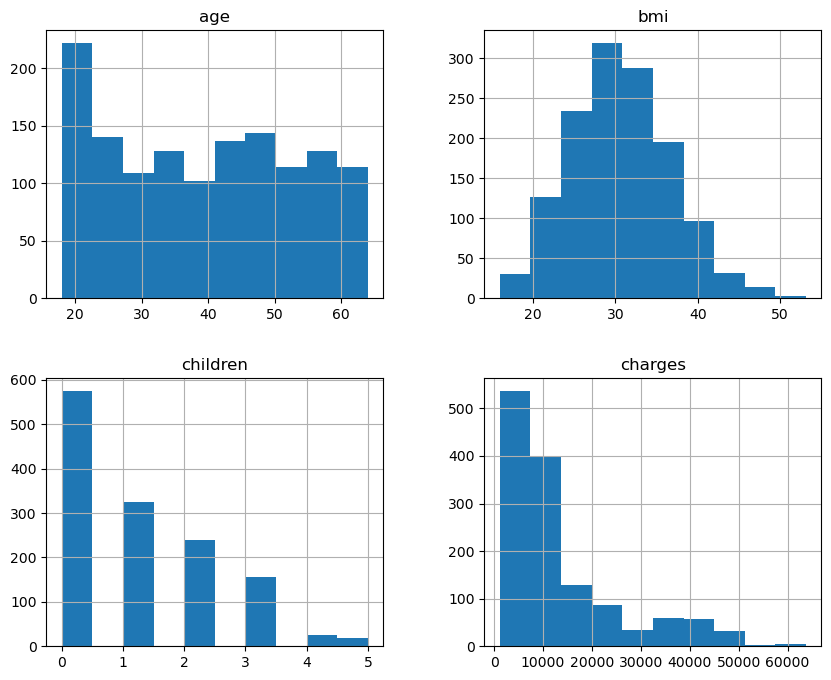

In [5]:
# now plotting a histograms to perform some basic eda
df.hist(figsize=(10,8))
plt.show()

In [6]:
#these four plots are stastics of no. of children, charge distribution, and bmi & age distribution 
# from this we can infer that all three of these categories are important factor for charges
# now we can plot a box plot to detect outliers if any

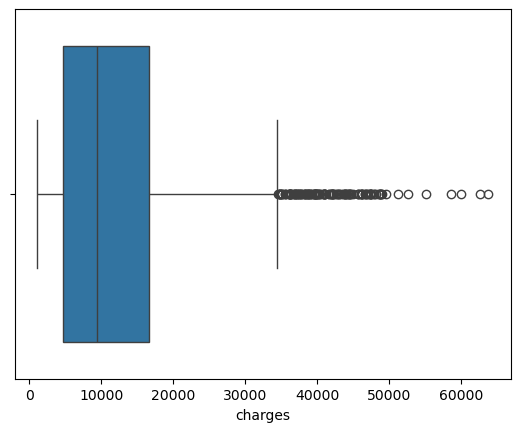

In [8]:
import seaborn as sns

sns.boxplot(x=df["charges"])
plt.show()

In [10]:
#the box plot is skewed right meaning most people have low to moderate charges but there are many outliers present on the right side of the plot 
# these could be individuals who smoke or have severe medical conditions which makes there charges rise drastically which in turn could affect our model

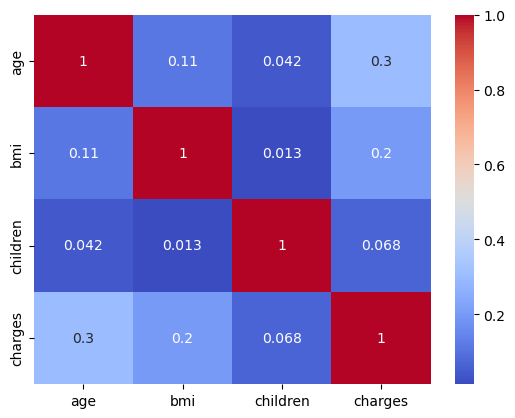

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [12]:
#this correlation heatmap shows that there is a high correlation(0.30) between age and charges and bmi has a moderate correlation(0.20) and children has 
# little to no correlation(0.06) but one important thing to note is that this does not include categorical columns like smoker which must have a high 
# correlation but aren't considered because they're not encoded yet


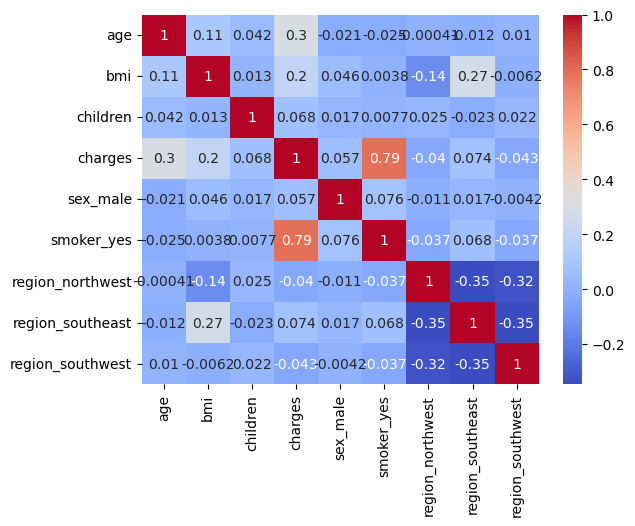

In [15]:
# now we encode the categorical columns and plot this again 
df = pd.get_dummies(df, drop_first=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [16]:
# Now we can see that smoker has the highest correlation(0.79) by far and age after that(0.30) and bmi hs slight 
# correlation(0.20) while factors like children(0.06) and gender(0.05) have almost no correlation and factors like regions 
# negative correlation 

In [20]:
# now we treat the outliers 
# Calculate Q1 and Q3
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)

# IQR
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Remove outliers
df_clean = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)]

# Check shape difference
print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)


Lower Bound: -8408.65215
Upper Bound: 25770.94265
Original shape: (1199, 9)
After removing outliers: (1144, 9)


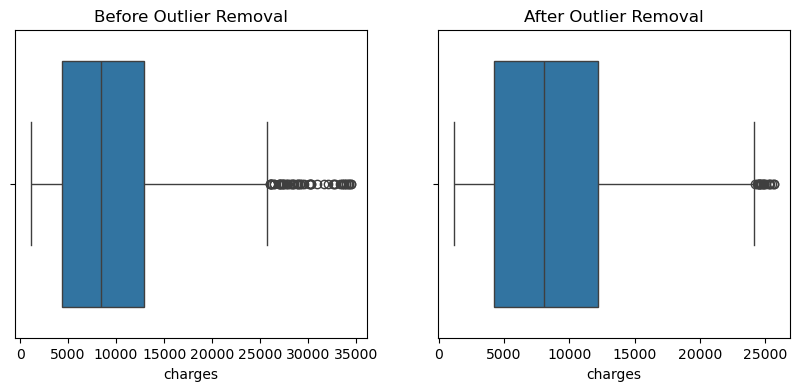

In [21]:
# Before
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.boxplot(x=df['charges'])
plt.title("Before Outlier Removal")

# After
plt.subplot(1,2,2)
sns.boxplot(x=df_clean['charges'])
plt.title("After Outlier Removal")

plt.show()

In [22]:
# now we've removed the extreme outliers and this helps us improve model performence as linear regression models are 
# susceptible to extreme values 


In [24]:
# Now we scale the dataset 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale after split
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)        

In [26]:
# Now comes part B 
X_train_scaled, X_test_scaled

(array([[-0.00486237, -0.85068029,  1.56953646, ..., -0.59059673,
         -0.59220286, -0.56169448],
        [ 0.71252419,  1.07286223,  1.56953646, ..., -0.59059673,
          1.68861056, -0.56169448],
        [-1.29615817,  1.54145947, -0.89663306, ..., -0.59059673,
          1.68861056, -0.56169448],
        ...,
        [-0.79398758,  1.14986947, -0.07457655, ..., -0.59059673,
         -0.59220286,  1.78032728],
        [-0.72224893, -0.68519665, -0.89663306, ..., -0.59059673,
         -0.59220286,  1.78032728],
        [ 1.07121747, -0.3992868 , -0.07457655, ...,  1.69320273,
         -0.59220286, -0.56169448]]),
 array([[-1.51137414, -0.29032975, -0.07457655, ..., -0.59059673,
         -0.59220286, -0.56169448],
        [-0.29181699, -0.48858242, -0.07457655, ..., -0.59059673,
         -0.59220286,  1.78032728],
        [-0.72224893, -0.35095247, -0.07457655, ..., -0.59059673,
          1.68861056, -0.56169448],
        ...,
        [-1.43963549, -0.29032975, -0.89663306, ...,  

In [27]:
# What my approach will be to train the model:
# first we input only one feature with the highest correlation(simple) and then all the factors(multiple) 


In [28]:
# Select only one feature
X_simple = df[['smoker_yes']]
y = df['charges']

# Train-test split
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Train model
from sklearn.linear_model import LinearRegression

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

# Predictions
y_pred_s = simple_model.predict(X_test_s)

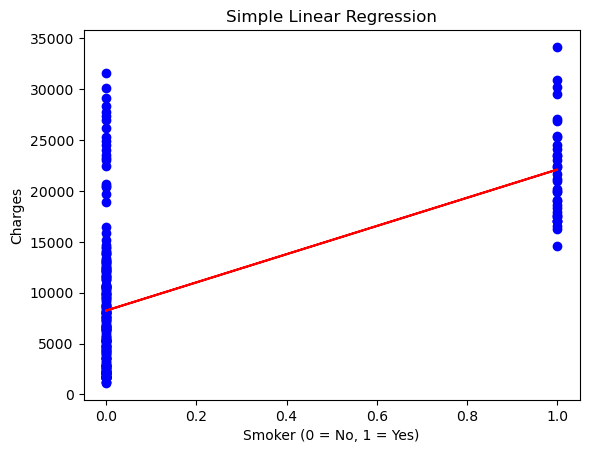

In [29]:
# Now we visualise the training done above 
plt.scatter(X_test_s, y_test_s, color='blue')
plt.plot(X_test_s, y_pred_s, color='red')
plt.xlabel("Smoker (0 = No, 1 = Yes)")
plt.ylabel("Charges")
plt.title("Simple Linear Regression")
plt.show()

In [30]:
# currently our simple regression model treats it like binary values(0 and 1) being smoker and non smoker 
# with non smoker having low charges and smokers having higher charges(the blue dots) and the red line connecting them is the
# linear regression plot of charges=b0​+b1​⋅smoker
# but this is not very accurate so we now implement the multiple model 


In [31]:
#Multiple regression
# Initialize model
multi_model = LinearRegression()

# Train using scaled data
multi_model.fit(X_train_scaled, y_train)

LinearRegression()

In [33]:
y_pred_train = multi_model.predict(X_train_scaled)
y_pred_test = multi_model.predict(X_test_scaled)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': multi_model.coef_
})

print(coefficients)

            Feature  Coefficient
0               age  3374.768793
1               bmi   466.509990
2          children   435.143854
3          sex_male  -226.956160
4        smoker_yes  4681.761858
5  region_northwest   -37.328730
6  region_southeast  -418.092268
7  region_southwest  -581.188219


In [34]:
# +ve coeff-> increases charges
# -ve coeff-> decreases charges
# we take smoker_yes (highest coeff) and age,bmi(+ve coeff)

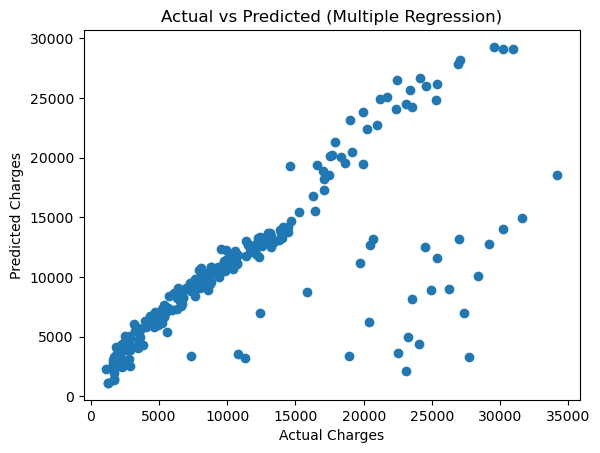

In [35]:
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted (Multiple Regression)")
plt.show()

In [37]:
# from this plot we can see that our model is performing quite well for the lower charges but struggles a bit for charges on the 
# higher side

In [39]:
#Now its time for evaluating the model 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Predictions
y_pred_train = multi_model.predict(X_train_scaled)
y_pred_test = multi_model.predict(X_test_scaled)

print("TRAIN METRICS:")
print(f"MAE: {mae_train:.2f}")
print(f"MSE: {mse_train:.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R2 Score: {r2_train:.4f}")

print("\nTEST METRICS:")
print(f"MAE: {mae_test:.2f}")
print(f"MSE: {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R2 Score: {r2_test:.4f}")

TRAIN METRICS:
MAE: 2389.10
MSE: 19044965.67
RMSE: 4364.05
R2 Score: 0.6169

TEST METRICS:
MAE: 2796.37
MSE: 27645846.66
RMSE: 5257.93
R2 Score: 0.5568


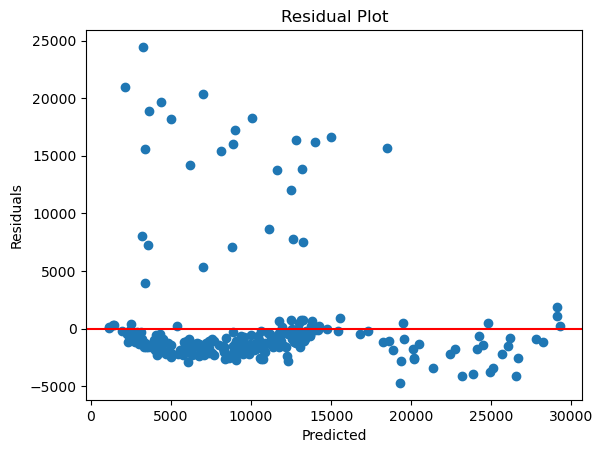

In [40]:
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [41]:
#The presence of heteroscedasticity and non-linearity suggests that 
#polynomial regression or regularization techniques may improve model performance

In [42]:
# GRADIENT DESCENT
# Use simple regression data
X = X_train_s.values.flatten()   # smoker (0 or 1)
y = y_train_s.values
# Initialize parameters
b0 = 0   # intercept
b1 = 0   # slope
learning_rate = 0.01
epochs = 1000
n = len(X)
# Gradient Descent loop
for i in range(epochs):    
    # Predictions
    y_pred = b0 + b1 * X  
    # Compute gradients
    db0 = (-2/n) * np.sum(y - y_pred)
    db1 = (-2/n) * np.sum(X * (y - y_pred))    
    # Update parameters
    b0 = b0 - learning_rate * db0
    b1 = b1 - learning_rate * db1

print("Intercept (b0):", b0)
print("Slope (b1):", b1)

Intercept (b0): 8476.398603333635
Slope (b1): 11946.286296685223


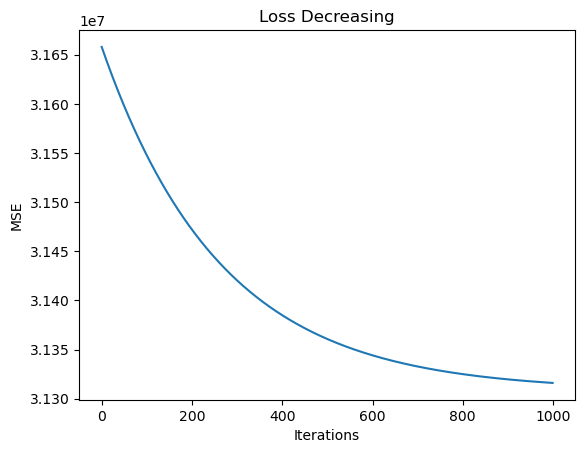

In [43]:
losses = []

for i in range(epochs):
    y_pred = b0 + b1 * X
    
    loss = np.mean((y - y_pred)**2)
    losses.append(loss)
    
    db0 = (-2/n) * np.sum(y - y_pred)
    db1 = (-2/n) * np.sum(X * (y - y_pred))
    
    b0 -= learning_rate * db0
    b1 -= learning_rate * db1

# Plot loss
import matplotlib.pyplot as plt
plt.plot(losses)
plt.title("Loss Decreasing")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

In [ ]:
#Loss (MSE) is steadily decreasing
#Curve is smooth and converging
#Gradient Descent is working correctly and finding the optimal parameters